# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


## Dataset Overview

This dataset contains over 600,000 individual ICE detention stay records between September 2023 and October 2025. Each row represents a single detention stay event with booking and release timestamps, legal status indicators, demographic attributes, and financial information.

---

## Target Variable

The target variable for this analysis is:

**`duration_days`** – the total number of days between booking (`stay_book_in_date_time`) and release (`stay_book_out_date_time`).

This variable represents the length of detention and will be treated as a continuous regression target.

---

## Selected Features

The following five features were selected for analysis based on their potential relationship to detention duration:

### 1. book_in_criminality
This feature classifies the legal/criminal status at intake (e.g., Convicted Criminal, Pending Criminal Charges, Immigration Violator).  
Reason for inclusion: Legal severity is likely to influence detention length and may be one of the strongest predictors of duration.

### 2. detention_release_reason
This feature indicates how the detention ended (e.g., Removed, Released, Other).  
Reason for inclusion: Different release pathways may correspond to systematically longer or shorter detention durations.

### 3. bond_posted_amount
This numeric feature records the amount of bond posted (if any).  
Reason for inclusion: Financial ability may influence duration. Individuals who are able to post bond may experience shorter detention periods. Missing values may also be informative.

### 4. gender
This demographic feature identifies detainee gender.  
Reason for inclusion: Demographic factors may reveal structural differences in detention length.

### 5. ethnicity
This feature identifies ethnic classification.  
Reason for inclusion: Examining ethnicity allows analysis of potential disparities or systemic differences in detention duration.

---

Each visualization will analyze the relationship between one of these features and the target variable (`duration_days`) to determine which factors appear most strongly associated with detention length.

In [14]:
# Step 1 (Updated): Load relevant columns including ethnicity

import pandas as pd

cols = [
    "stay_book_in_date_time",
    "stay_book_out_date_time",
    "detention_release_reason",
    "gender",
    "ethnicity",  # Added
    "bond_posted_amount",
    "book_in_criminality"
]

df = pd.read_csv(
    "detention-stays-latest.csv",
    usecols=cols,
    parse_dates=["stay_book_in_date_time", "stay_book_out_date_time"]
)

print(df.shape)
df.head()

(671750, 7)


,stay_book_in_date_time,stay_book_out_date_time,detention_release_reason,gender,ethnicity,bond_posted_amount,book_in_criminality
0,2025-05-19 22:35:00+00:00,2025-06-02 07:02:00+00:00,Removed,Male,NaN,NaN,2 Pending Criminal Charges
1,2023-09-23 12:00:00+00:00,2023-11-27 14:56:00+00:00,Removed,Male,Hispanic Origin,NaN,1 Convicted Criminal
2,2024-02-10 11:08:00+00:00,2024-04-05 11:02:00+00:00,Removed,Male,NaN,NaN,3 Other Immigration Violator
3,2023-11-09 11:31:00+00:00,2023-12-18 16:46:00+00:00,Removed,Male,Hispanic Origin,NaN,1 Convicted Criminal
4,2025-09-11 11:10:00+00:00,2025-09-16 04:30:00+00:00,Removed,Male,Hispanic Origin,NaN,1 Convicted Criminal


In [15]:
# Step 2: Explore values for each selected feature

# 1. Criminality categories
print("Book In Criminality Value Counts:")
print(df["book_in_criminality"].value_counts(dropna=False))
print("\n")

# 2. Release reason categories
print("Detention Release Reason Value Counts:")
print(df["detention_release_reason"].value_counts(dropna=False))
print("\n")

# 3. Gender categories
print("Gender Value Counts:")
print(df["gender"].value_counts(dropna=False))
print("\n")

# 4. Ethnicity categories (may be many)
print("Ethnicity Value Counts:")
print(df["ethnicity"].value_counts(dropna=False))
print("\n")

# 5. Bond posted amount summary
print("Bond Posted Amount Summary:")
print(df["bond_posted_amount"].describe())
print("\n")

print("Bond Posted Amount Missing Values:")
print(df["bond_posted_amount"].isna().sum())

Book In Criminality Value Counts:
book_in_criminality
3 Other Immigration Violator    360045
1 Convicted Criminal            198515
2 Pending Criminal Charges      113190
Name: count, dtype: int64


Detention Release Reason Value Counts:
detention_release_reason
Removed                                                          399767
NaN                                                               61618
Paroled                                                           50308
Order of recognizance                                             32269
Bonded Out - IJ                                                   24723
Paroled - Fear Found                                              24498
Transferred                                                       19174
U.S. Marshals or other agency (explain in Detention Comments)     16499
Paroled - Humanitarian                                            11125
Order of supervision                                               7652
Order of Recogniz

## Feature Value Summary

Below are the observed values for each selected feature:

### 1. book_in_criminality
- Other Immigration Violator (~360,000)
- Convicted Criminal (~198,000)
- Pending Criminal Charges (~111,000)

The majority of cases are classified as Other Immigration Violator.

---

### 2. detention_release_reason
The most common release outcomes are:
- Removed (~399,000)
- Paroled (~50,000)
- Order of Recognizance (~32,000)
- Bonded Out – IJ (~24,000)
- Paroled – Fear Found (~24,000)

There are many additional smaller categories. A substantial number of records have missing release reasons.

---

### 3. gender
- Male (~568,000)
- Female (~103,000)
- Unknown (~200)

The dataset is heavily male-dominated.

---

### 4. ethnicity
- Hispanic Origin (~245,000)
- Not of Hispanic Origin (~20,000)
- Unknown (~4,800)
- Missing (~400,000)

The dataset is overwhelmingly male-dominated. This imbalance may limit the predictive influence of gender in modeling detention duration. Any observed differences in duration by gender must be interpreted carefully due to the large disparity in group sizes.

---

### 5. bond_posted_amount
- Mean: ~$6,969
- Median: $5,000
- Range: $50 – $150,000
- Missing values: ~628,000

Ethnicity contains substantial missing data, with a majority of records lacking classification. This limits its reliability as a predictor. The high proportion of Hispanic origin among known values suggests demographic concentration, but modeling use would require careful handling of missingness.

In [16]:
df["duration_days"] = (
    df["stay_book_out_date_time"] - df["stay_book_in_date_time"]
).dt.total_seconds() / (60 * 60 * 24)

# Remove invalid durations (data errors)
df = df[df["duration_days"] > 0].copy()

print(df[["stay_book_in_date_time", "stay_book_out_date_time", "duration_days"]].head())
print(df["duration_days"].describe())

     stay_book_in_date_time   stay_book_out_date_time  duration_days
0 2025-05-19 22:35:00+00:00 2025-06-02 07:02:00+00:00      13.352083
1 2023-09-23 12:00:00+00:00 2023-11-27 14:56:00+00:00      65.122222
2 2024-02-10 11:08:00+00:00 2024-04-05 11:02:00+00:00      54.995833
3 2023-11-09 11:31:00+00:00 2023-12-18 16:46:00+00:00      39.218750
4 2025-09-11 11:10:00+00:00 2025-09-16 04:30:00+00:00       4.722222
count    606530.000000
mean         48.363598
std          71.506617
min           0.000694
25%           8.812500
50%          28.077083
75%          58.761111
max        7354.000000
Name: duration_days, dtype: float64


<Figure size 800x500 with 0 Axes>

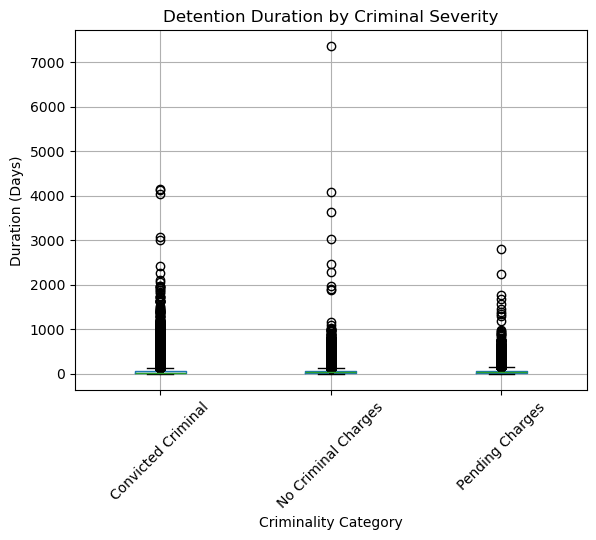

In [17]:
# Visualization 1: Duration by Criminality Level

import matplotlib.pyplot as plt

# Create cleaner labels
criminality_map = {
    "3 Other Immigration Violator": "No Criminal Charges",
    "2 Pending Criminal Charges": "Pending Charges",
    "1 Convicted Criminal": "Convicted Criminal"
}

df["criminality_clean"] = df["book_in_criminality"].map(criminality_map)

# Define logical order
order = ["No Criminal Charges", "Pending Charges", "Convicted Criminal"]

plt.figure(figsize=(8,5))
df.boxplot(
    column="duration_days",
    by="criminality_clean",
    rot=45
)

plt.title("Detention Duration by Criminal Severity")
plt.suptitle("")
plt.xlabel("Criminality Category")
plt.ylabel("Duration (Days)")
plt.show()

### Interpretation: Criminal Severity vs Duration

This boxplot compares detention duration across criminal severity levels. All three categories show strong right skew with substantial long-duration outliers, indicating that while most detention stays are relatively short, a small number extend for years.

Median detention durations appear broadly similar across No Criminal Charges, Pending Charges, and Convicted Criminal groups. Although No Criminal Charges cases show slightly more extreme high-duration outliers, the overall distributions overlap considerably.

This suggests that criminal severity alone is not a strong predictor of detention length. Other structural or procedural factors likely play a significant role in determining duration.

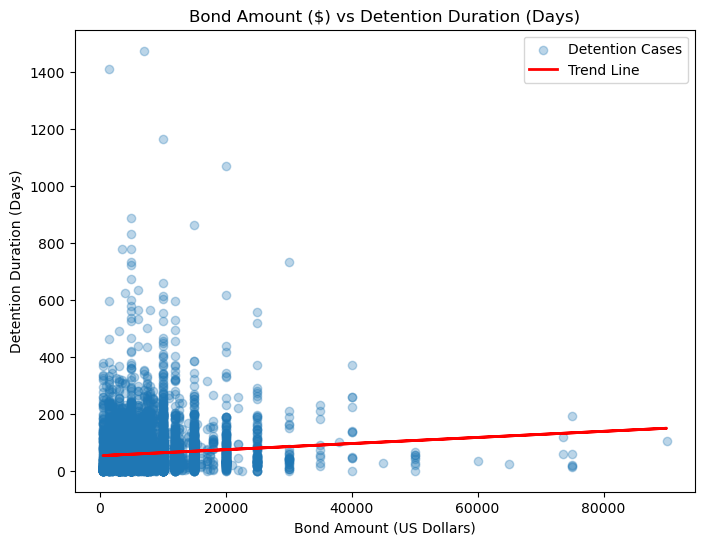

Correlation (r): 0.081


In [22]:
# Visualization 2: Bond Amount vs Detention Duration

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Keep only rows with bond posted
bond_df = df[df["bond_posted_amount"].notna()].copy()

# Sample to avoid overplotting
bond_sample = bond_df.sample(n=10000, random_state=42)

x = bond_sample["bond_posted_amount"]
y = bond_sample["duration_days"]

# Fit simple linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)
trend_line = intercept + slope * x

plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.3, label="Detention Cases")
plt.plot(x, trend_line, color="red", linewidth=2, label="Trend Line")

plt.title("Bond Amount ($) vs Detention Duration (Days)")
plt.xlabel("Bond Amount (US Dollars)")
plt.ylabel("Detention Duration (Days)")
plt.legend()

plt.show()

print("Correlation (r):", round(r_value, 3))

In [23]:
# Check median duration for high bond cases only

high_bond = bond_df[bond_df["bond_posted_amount"] > 50000]

print("High bond count:", high_bond.shape[0])
print("High bond median duration:", high_bond["duration_days"].median())

High bond count: 26
High bond median duration: 57.409375


In [24]:
print("Overall bond median duration:", bond_df["duration_days"].median())

Overall bond median duration: 39.81805555555555


### Interpretation: Bond Amount vs Detention Duration

At first glance, the scatter plot may appear to suggest that very high bond amounts correspond to shorter detention durations. However, further analysis shows this is not supported by the data. Among cases with bond amounts above $50,000 (n = 26), the median detention duration is approximately 57 days, compared to an overall median of approximately 40 days for all bond cases. This confirms that the apparent pattern at the extreme high end of bond values is driven by small sample size rather than a true inverse relationship.

Overall, bond amount demonstrates only a weak association with detention duration and does not appear to be a strong standalone predictor of how long an individual remains detained.

<Figure size 800x500 with 0 Axes>

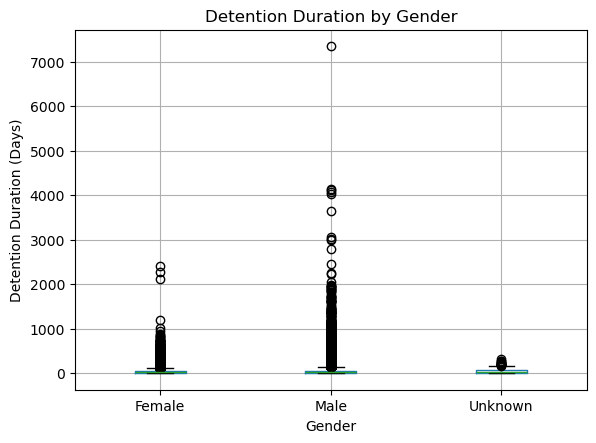

In [25]:
# Visualization 3: Duration by Gender

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df.boxplot(column="duration_days", by="gender")

plt.title("Detention Duration by Gender")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Detention Duration (Days)")

plt.show()

In [26]:
# Median duration by gender
print("Median Duration by Gender:")
print(df.groupby("gender")["duration_days"].median())

Median Duration by Gender:
gender
Female     28.184375
Male       28.059028
Unknown    32.342361
Name: duration_days, dtype: float64


### Interpretation: Gender vs Detention Duration

This boxplot compares detention duration across gender categories. The median detention duration is nearly identical for males (28.06 days) and females (28.18 days), indicating no meaningful difference between the two groups. The “Unknown” category shows a slightly higher median (32.34 days), but this group is much smaller and may not be directly comparable.

All gender groups display strong right skew with substantial outliers, suggesting that while most detention stays are relatively short, a small number extend to very long durations. Overall, gender does not appear to be a strong predictor of detention duration in this dataset.

In [27]:
# Remove missing ethnicity values for clarity
eth_df = df[df["ethnicity"].notna()].copy()

print("Ethnicity Counts:")
print(eth_df["ethnicity"].value_counts())

Ethnicity Counts:
ethnicity
Hispanic Origin           216231
Not of Hispanic Origin     14205
Unknown                     4108
Name: count, dtype: int64


<Figure size 800x500 with 0 Axes>

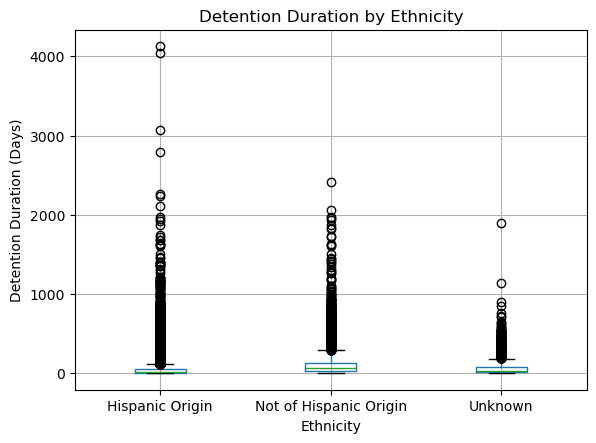

In [28]:
# Visualization 4: Duration by Ethnicity

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

eth_df.boxplot(column="duration_days", by="ethnicity")

plt.title("Detention Duration by Ethnicity")
plt.suptitle("")
plt.xlabel("Ethnicity")
plt.ylabel("Detention Duration (Days)")

plt.show()

In [29]:
print("Median Duration by Ethnicity:")
print(eth_df.groupby("ethnicity")["duration_days"].median())

Median Duration by Ethnicity:
ethnicity
Hispanic Origin           22.068750
Not of Hispanic Origin    63.940972
Unknown                   35.771181
Name: duration_days, dtype: float64


### Interpretation: Ethnicity vs Detention Duration

This boxplot compares detention duration across ethnicity categories (excluding missing values). The median detention duration for individuals of Hispanic origin is approximately 22 days, while the median for individuals not of Hispanic origin is approximately 64 days. The “Unknown” category falls between these groups at approximately 36 days.

This represents a substantial difference in median detention length between the two primary ethnicity groups. Individuals classified as Not of Hispanic Origin experience considerably longer median detention durations compared to those classified as Hispanic Origin. While all groups display right-skewed distributions with long-duration outliers, ethnicity appears to show a stronger relationship with detention duration than gender or bond amount in this dataset.

In [34]:
# Create release categories

criminality_map = {
    "1 Convicted Criminal": "Convicted Criminal",
    "2 Pending Criminal Charges": "Pending Charges",
    "3 Other Immigration Violator": "No Criminal Charges"
}

df["criminality_clean"] = df["book_in_criminality"].map(criminality_map)

# Keep only mapped rows
release_df = df[df["criminality_clean"].notna() & df["release_clean"].notna()].copy()

In [35]:
# Create percentage table
release_table = pd.crosstab(
    release_df["criminality_clean"],
    release_df["release_clean"],
    normalize="index"
)

# Force logical order
release_table = release_table.loc[
    ["No Criminal Charges", "Pending Charges", "Convicted Criminal"]
]

print(release_table)

release_clean        Bonded Out   Paroled  Recognized   Removed  Transferred  \
criminality_clean                                                              
No Criminal Charges    0.048410  0.175524    0.088163  0.621438     0.056528   
Pending Charges        0.099953  0.008975    0.047305  0.811015     0.013958   
Convicted Criminal     0.035661  0.004028    0.016274  0.926002     0.011598   

release_clean        Voluntary Departure  
criminality_clean                         
No Criminal Charges             0.009936  
Pending Charges                 0.018794  
Convicted Criminal              0.006438  


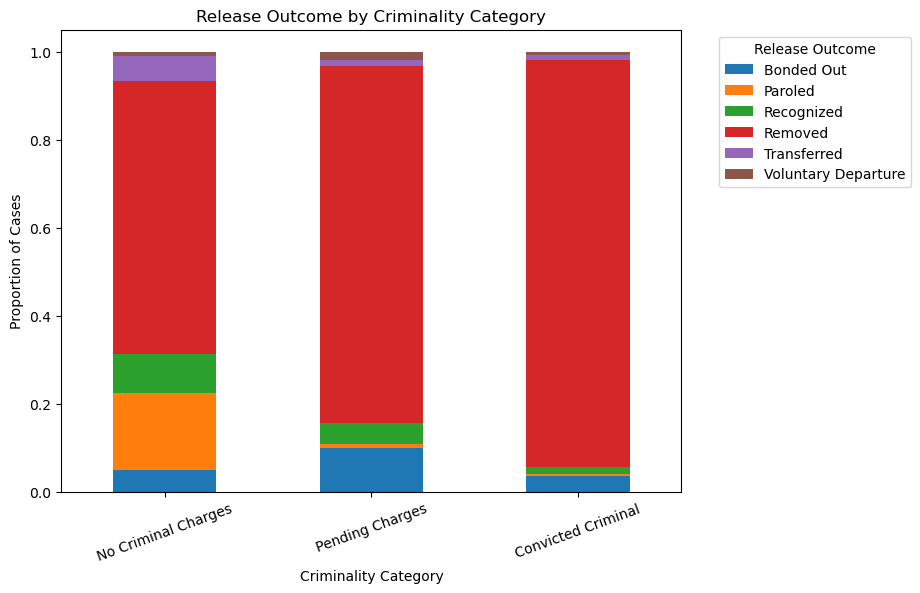

In [36]:
import matplotlib.pyplot as plt

release_table.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6)
)

plt.title("Release Outcome by Criminality Category")
plt.xlabel("Criminality Category")
plt.ylabel("Proportion of Cases")
plt.legend(title="Release Outcome", bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=20)
plt.show()

### Interpretation: Criminality Category vs Release Outcome

This stacked bar chart shows the proportion of release outcomes within each criminality category. Individuals with No Criminal Charges experience the most varied outcomes. While removal remains the majority outcome (approximately 62%), parole, recognizance, bonding out, and transfers occur at meaningful rates.

For individuals with Pending Charges, removal increases substantially to approximately 81%, and alternative release mechanisms become less common.

Among Convicted Criminals, removal becomes overwhelmingly dominant (approximately 93%), with very small proportions bonded out, paroled, or recognized.

These results indicate that criminal severity strongly influences how detention ends. As criminal involvement increases, removal becomes more likely and release flexibility decreases significantly.

In [38]:
# Load only the columns needed to compute repeat detentions
import pandas as pd

repeat_df = pd.read_csv(
    "detention-stays-latest.csv",
    usecols=["stay_ID", "unique_identifier"]
)

total_stays = repeat_df["stay_ID"].nunique()
total_people = repeat_df["unique_identifier"].nunique()

stays_per_person = repeat_df.groupby("unique_identifier")["stay_ID"].nunique()
repeat_detainees = (stays_per_person > 1).sum()

print("Total detention stays:", total_stays)
print("Total unique individuals:", total_people)
print("People detained more than once:", repeat_detainees)
print("Percent repeat detainees:", round(100 * repeat_detainees / total_people, 2), "%")

Total detention stays: 671750
Total unique individuals: 637020
People detained more than once: 32548
Percent repeat detainees: 5.11 %


In [40]:
# Build person-level repeat flag from the full file

import pandas as pd

repeat_base = pd.read_csv(
    "detention-stays-latest.csv",
    usecols=["stay_ID", "unique_identifier"]
)

stays_per_person = repeat_base.groupby("unique_identifier")["stay_ID"].nunique()

repeat_flag_df = (stays_per_person > 1).reset_index()
repeat_flag_df.columns = ["unique_identifier", "is_repeat"]

print(repeat_flag_df["is_repeat"].value_counts())

is_repeat
False    604472
True      32548
Name: count, dtype: int64


In [44]:
# Load features + IDs so we can analyze repeat patterns

cols_repeat = [
    "stay_ID",
    "unique_identifier",
    "gender",
    "ethnicity",
    "book_in_criminality"
]

df_repeat = pd.read_csv(
    "detention-stays-latest.csv",
    usecols=cols_repeat
)

# Merge repeat flag onto each stay row
df_repeat = df_repeat.merge(repeat_flag_df, on="unique_identifier", how="left")

# Sanity check
print(df_repeat[["stay_ID", "unique_identifier", "is_repeat", "gender", "ethnicity", "book_in_criminality"]].head())
print(df_repeat["is_repeat"].value_counts())

                                             stay_ID  \
0  000033bd6a1712721982e3cc31fa5efe203aa033_2025-...   
1  00007cb10d7edd5e97cbefad22016c1679d98343_2023-...   
2  000086ed0144f7adc8cf34591b321db280497912_2024-...   
3  00008df187d556536d9799c5a3e889cbca52ae48_2023-...   
4  00008df187d556536d9799c5a3e889cbca52ae48_2025-...   

                          unique_identifier  is_repeat gender  \
0  000033bd6a1712721982e3cc31fa5efe203aa033      False   Male   
1  00007cb10d7edd5e97cbefad22016c1679d98343      False   Male   
2  000086ed0144f7adc8cf34591b321db280497912      False   Male   
3  00008df187d556536d9799c5a3e889cbca52ae48       True   Male   
4  00008df187d556536d9799c5a3e889cbca52ae48       True   Male   

         ethnicity           book_in_criminality  
0              NaN    2 Pending Criminal Charges  
1  Hispanic Origin          1 Convicted Criminal  
2              NaN  3 Other Immigration Violator  
3  Hispanic Origin          1 Convicted Criminal  
4  Hispanic Origi

Criminality distribution (column-normalized):
is_repeat               False     True 
criminality_clean                      
Convicted Criminal   0.276036  0.470570
No Criminal Charges  0.558552  0.333185
Pending Charges      0.165412  0.196245


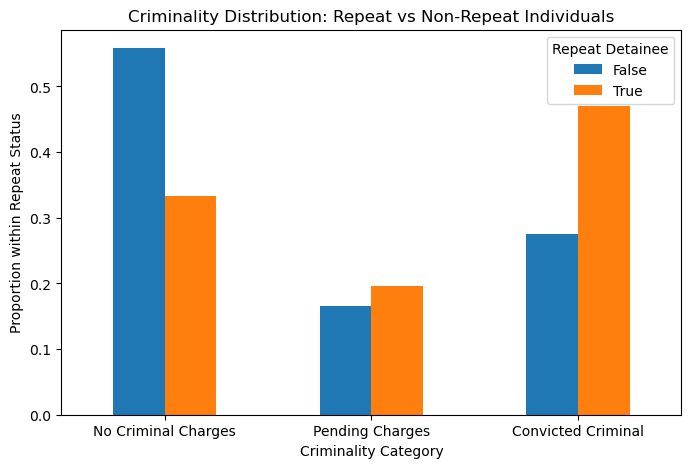

In [47]:
import matplotlib.pyplot as plt

criminality_map = {
    "3 Other Immigration Violator": "No Criminal Charges",
    "2 Pending Criminal Charges": "Pending Charges",
    "1 Convicted Criminal": "Convicted Criminal"
}

df_repeat["criminality_clean"] = df_repeat["book_in_criminality"].map(criminality_map)

# Create normalized cross-tab (column normalized so we compare repeat vs non-repeat properly)
criminality_repeat = pd.crosstab(
    df_repeat["criminality_clean"],
    df_repeat["is_repeat"],
    normalize="columns"
)

print("Criminality distribution (column-normalized):")
print(criminality_repeat)

# Reorder rows for logical presentation
order = ["No Criminal Charges", "Pending Charges", "Convicted Criminal"]
criminality_repeat = criminality_repeat.loc[order]

# Plot
criminality_repeat.plot(kind="bar", figsize=(8,5))

plt.title("Criminality Distribution: Repeat vs Non-Repeat Individuals")
plt.xlabel("Criminality Category")
plt.ylabel("Proportion within Repeat Status")
plt.legend(title="Repeat Detainee")
plt.xticks(rotation=0)
plt.show()

Gender distribution (column-normalized):
is_repeat     False     True 
gender                       
Female     0.160462  0.096049
Male       0.839230  0.903832
Unknown    0.000308  0.000119


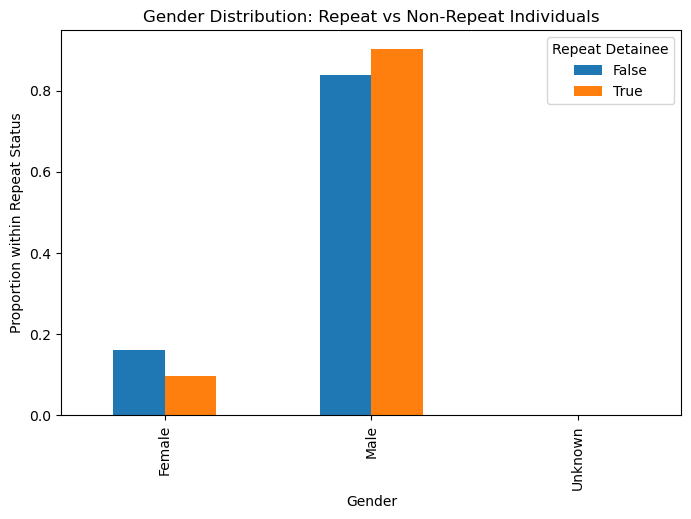

In [48]:
gender_repeat = pd.crosstab(
    df_repeat["gender"],
    df_repeat["is_repeat"],
    normalize="columns"
)

print("Gender distribution (column-normalized):")
print(gender_repeat)

gender_repeat.plot(kind="bar", figsize=(8,5))
plt.title("Gender Distribution: Repeat vs Non-Repeat Individuals")
plt.xlabel("Gender")
plt.ylabel("Proportion within Repeat Status")
plt.legend(title="Repeat Detainee")
plt.show()

Ethnicity distribution (column-normalized):
is_repeat                  False     True 
ethnicity                                 
Hispanic Origin         0.904804  0.913799
Not of Hispanic Origin  0.077529  0.067694
Unknown                 0.017667  0.018507


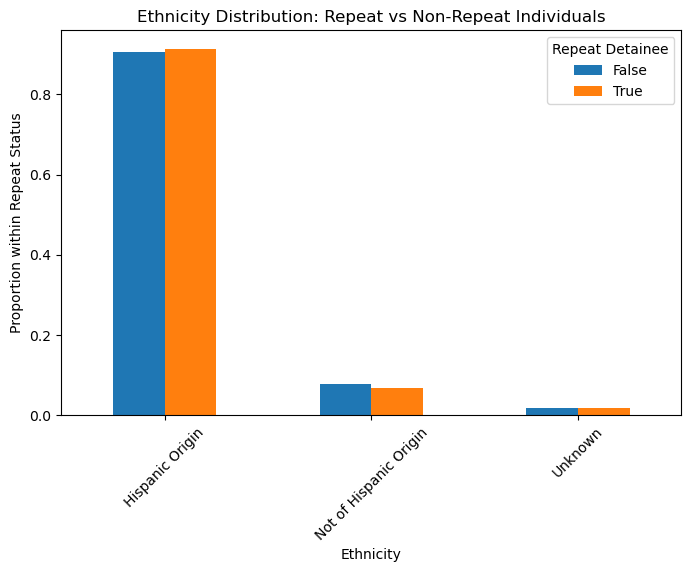

In [49]:
ethnicity_repeat = pd.crosstab(
    df_repeat["ethnicity"],
    df_repeat["is_repeat"],
    normalize="columns"
)

print("Ethnicity distribution (column-normalized):")
print(ethnicity_repeat)

ethnicity_repeat.plot(kind="bar", figsize=(8,5))
plt.title("Ethnicity Distribution: Repeat vs Non-Repeat Individuals")
plt.xlabel("Ethnicity")
plt.ylabel("Proportion within Repeat Status")
plt.legend(title="Repeat Detainee")
plt.xticks(rotation=45)
plt.show()

### Interpretation: Repeat Detainees

Approximately **5.11%** of individuals were detained more than once.

Repeat detainees are disproportionately concentrated in the **Convicted Criminal** category and less represented among individuals with **No Criminal Charges**. This suggests that criminal classification is strongly associated with repeat ICE contact.

Gender differences among repeat detainees are minimal relative to the overall population distribution.

Ethnicity patterns largely mirror the overall dataset: the majority of repeat detainees are of **Hispanic Origin**, but this reflects the broader composition of the detained population rather than a dramatic shift specific to repeat cases. There is no strong evidence here that repeat detention is disproportionately concentrated in one ethnicity beyond the baseline distribution of the dataset.

## Final Conclusion

Across all analyses, **criminal classification is the strongest and most consistent predictor** of detention outcomes.

As criminal severity increases:
- Removal becomes substantially more likely.
- Alternative release mechanisms decline.
- Repeat detention becomes more common.

Bond amount shows only a weak relationship with detention duration, and gender differences in detention length are minimal.

Ethnicity differences in detention duration are observable — with non-Hispanic individuals showing higher median durations — but these results must be interpreted cautiously due to missing data and potential structural factors not captured in this dataset.

Overall, detention outcomes appear to be shaped primarily by legal classification and case status rather than financial or demographic characteristics alone.